# 🐦 Twitter Sentiment Analysis — Full ML Pipeline
### BERT Embeddings + Logistic Regression + Naive Bayes + SVM
---
> **Pipeline:** EDA Before → Smart Preprocessing (no mass drops) → EDA After → BERT Embeddings → Train 3 Models → Evaluate → Export for Streamlit

## 📦 1. Install Libraries

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud joblib transformers torch tqdm

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re, string, os, warnings, joblib, json
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

import torch
from transformers import AutoTokenizer, AutoModel
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)

COLORS   = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#3498db'}
COLORS5  = {
    'strongly positive': '#1a9641',
    'positive':          '#a6d96a',
    'neutral':           '#3498db',
    'negative':          '#fdae61',
    'strongly negative': '#d7191c'
}
print('All libraries imported!')

All libraries imported!


## 📂 2. Load Data

In [2]:
train_df = pd.read_csv('train.csv', encoding='latin-1')
test_df  = pd.read_csv('test.csv',  encoding='latin-1')

print(f'Train shape : {train_df.shape}')
print(f'Test shape  : {test_df.shape}')
print(f'Columns     : {train_df.columns.tolist()}')
train_df.head()

Train shape : (6161, 10)
Test shape  : (4815, 9)
Columns     : ['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797.0,27400.0,105.0
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265.0,470.0,164.0
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272.0,1246700.0,26.0


In [3]:
print('=== NULL VALUES (before preprocessing) ===')
print(train_df.isnull().sum())
print('\n=== SENTIMENT DISTRIBUTION ===')
print(train_df['sentiment'].value_counts())

=== NULL VALUES (before preprocessing) ===
textID              0
text                1
selected_text       2
sentiment           1
Time of Tweet       1
Age of User         1
Country             1
Population -2020    1
Land Area (Km²)     1
Density (P/Km²)     1
dtype: int64

=== SENTIMENT DISTRIBUTION ===
sentiment
neutral     2502
positive    1961
negative    1697
Name: count, dtype: int64


## 📊 3. EDA — BEFORE Preprocessing

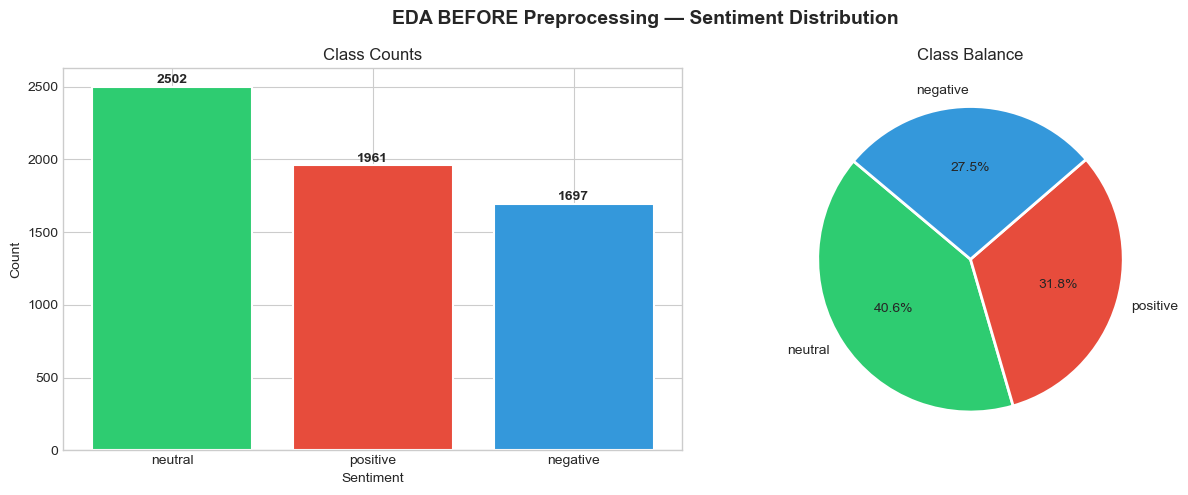

In [4]:
# 3.1 Sentiment Distribution
sc = train_df['sentiment'].value_counts()
c3 = [COLORS['positive'], COLORS['negative'], COLORS['neutral']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('EDA BEFORE Preprocessing — Sentiment Distribution', fontsize=14, fontweight='bold')

axes[0].bar(sc.index, sc.values, color=c3, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Counts'); axes[0].set_xlabel('Sentiment'); axes[0].set_ylabel('Count')
for i, v in enumerate(sc.values):
    axes[0].text(i, v+25, str(v), ha='center', fontweight='bold')

axes[1].pie(sc.values, labels=sc.index, autopct='%1.1f%%', colors=c3,
            startangle=140, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Balance')
plt.tight_layout()
plt.savefig('eda_before_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

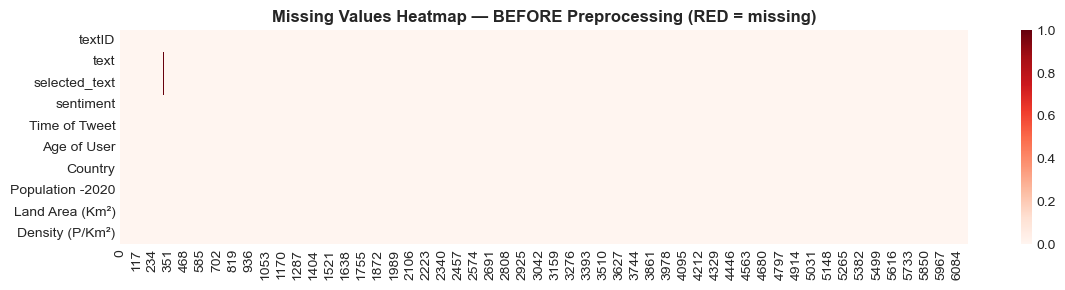

In [5]:
# 3.2 Null values heatmap BEFORE
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(train_df.isnull().T, cbar=True, cmap='Reds', ax=ax)
ax.set_title('Missing Values Heatmap — BEFORE Preprocessing (RED = missing)', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_before_nulls.png', dpi=150, bbox_inches='tight')
plt.show()

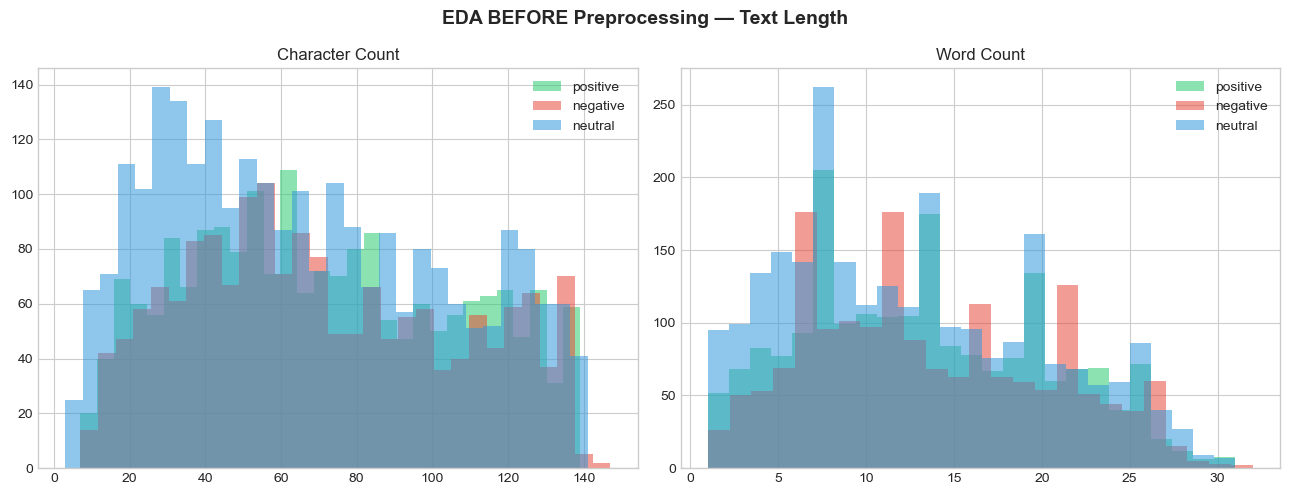

In [6]:
# 3.3 Text length distributions BEFORE
train_df['char_raw'] = train_df['text'].astype(str).apply(len)
train_df['word_raw'] = train_df['text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('EDA BEFORE Preprocessing — Text Length', fontsize=14, fontweight='bold')
for s, c in COLORS.items():
    sub = train_df[train_df['sentiment'] == s]
    axes[0].hist(sub['char_raw'], alpha=0.55, label=s, color=c, bins=30)
    axes[1].hist(sub['word_raw'], alpha=0.55, label=s, color=c, bins=25)
for ax, title in zip(axes, ['Character Count','Word Count']):
    ax.set_title(title); ax.legend()
plt.tight_layout()
plt.savefig('eda_before_length.png', dpi=150, bbox_inches='tight')
plt.show()

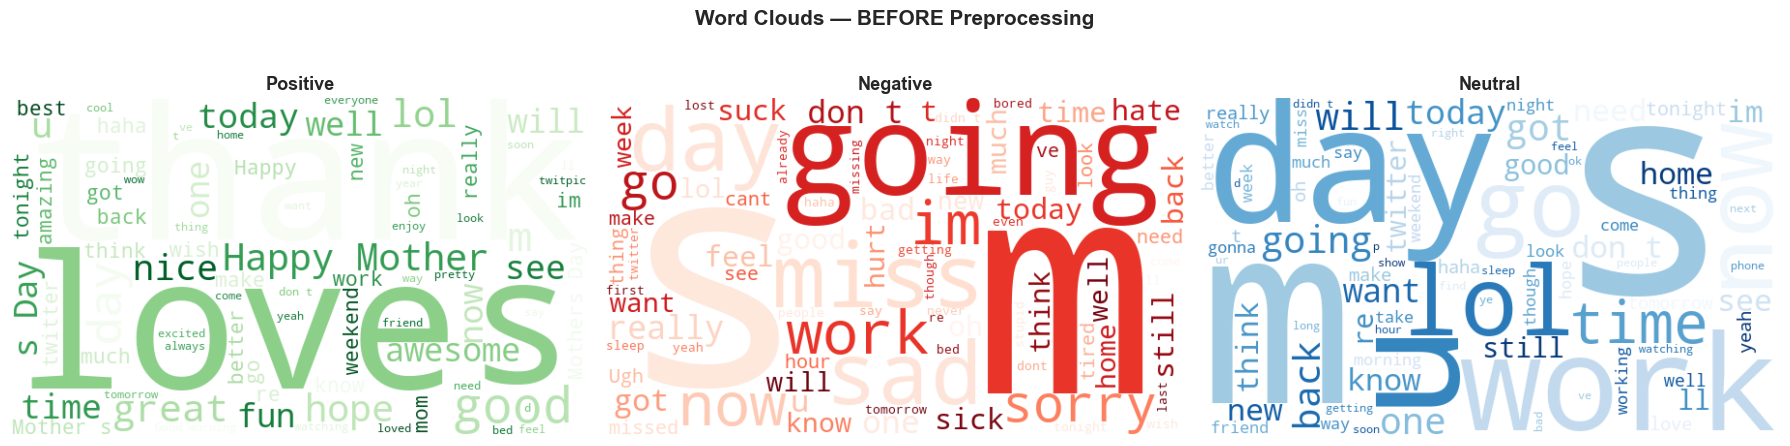

In [7]:
# 3.4 Word Clouds BEFORE cleaning
cmaps = ['Greens', 'Reds', 'Blues']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Word Clouds — BEFORE Preprocessing', fontsize=15, fontweight='bold')
for ax, s, cm in zip(axes, ['positive','negative','neutral'], cmaps):
    txt = ' '.join(train_df[train_df['sentiment']==s]['text'].dropna().astype(str))
    wc = WordCloud(width=600, height=350, background_color='white',
                   colormap=cm, max_words=80).generate(txt)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(s.capitalize(), fontsize=13, fontweight='bold'); ax.axis('off')
plt.tight_layout()
plt.savefig('eda_before_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

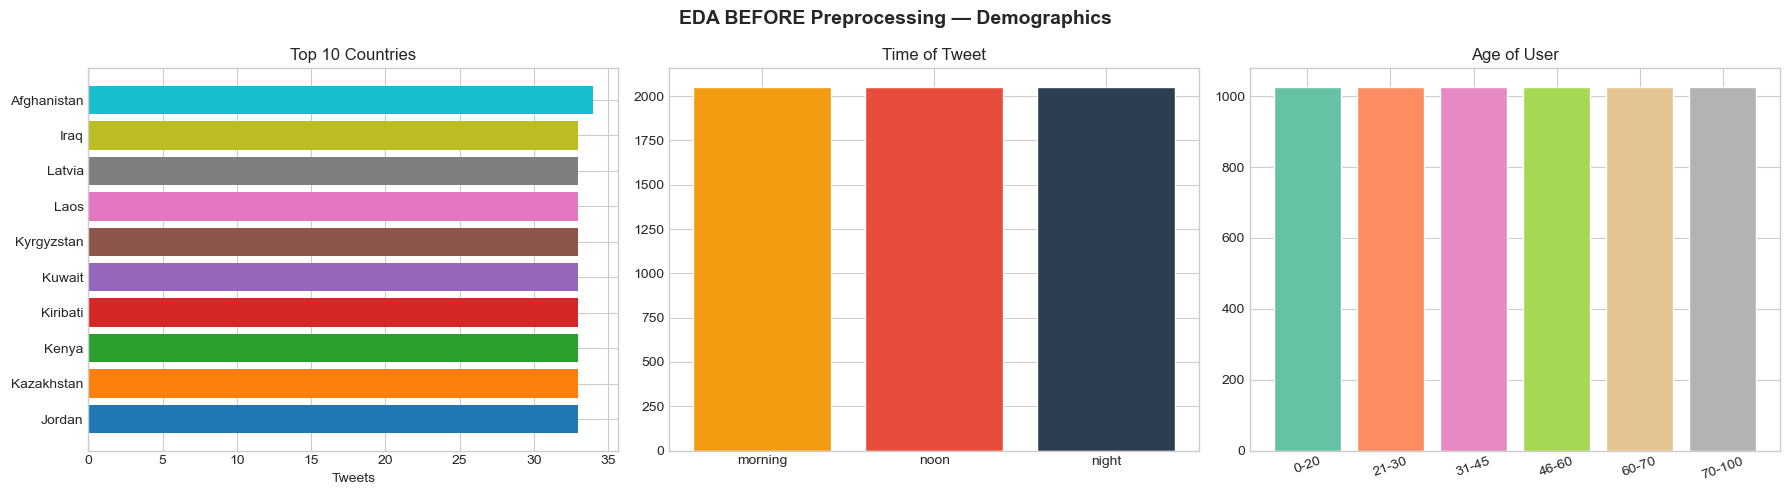

In [8]:
# 3.5 Demographics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EDA BEFORE Preprocessing — Demographics', fontsize=14, fontweight='bold')

cc = train_df['Country'].value_counts().head(10)
axes[0].barh(cc.index[::-1], cc.values[::-1], color=plt.cm.tab10(np.linspace(0,1,10)))
axes[0].set_title('Top 10 Countries'); axes[0].set_xlabel('Tweets')

tc = train_df['Time of Tweet'].value_counts()
axes[1].bar(tc.index, tc.values, color=['#f39c12','#e74c3c','#2c3e50'], edgecolor='white')
axes[1].set_title('Time of Tweet')

ac = train_df['Age of User'].value_counts()
axes[2].bar(ac.index, ac.values, color=plt.cm.Set2(np.linspace(0,1,len(ac))), edgecolor='white')
axes[2].set_title('Age of User'); axes[2].set_xticklabels(ac.index, rotation=20)

plt.tight_layout()
plt.savefig('eda_before_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

## 🧹 4. Smart Preprocessing — Impute, Don't Drop

In [9]:
# 4.1 Impute ALL nulls — zero rows dropped
def impute_df(df, is_train=True):
    df = df.copy()
    df['text'] = df['text'].fillna('')
    if 'selected_text' in df.columns:
        df['selected_text'] = df['selected_text'].fillna(df['text'])
    if is_train:
        df['sentiment'] = df['sentiment'].fillna(df['sentiment'].mode()[0])
    for col in ['Time of Tweet', 'Age of User', 'Country']:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mode()[0])
    for col in ['Population -2020', 'Land Area (Km\u00b2)', 'Density (P/Km\u00b2)']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].fillna(df[col].median())
    return df

train_df = impute_df(train_df, is_train=True)
test_df  = impute_df(test_df,  is_train=False)

print(f'Rows kept — Train: {len(train_df)} / Test: {len(test_df)} (0 dropped)')
print('\nNulls after imputation:')
print(train_df.isnull().sum())

Rows kept — Train: 6161 / Test: 4815 (0 dropped)

Nulls after imputation:
textID              0
text                0
selected_text       0
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
char_raw            0
word_raw            0
dtype: int64


In [10]:
# 4.2 Text Cleaning — keep negation words for accuracy
STOP_WORDS = set(stopwords.words('english'))
NEGATIONS  = {'not','no','nor','never','nobody','nothing','neither','nowhere','none',
               'cannot','cant','dont','wont','isnt','arent','wasnt','werent',
               'hasnt','havent','hadnt','doesnt','didnt','wouldnt','shouldnt','couldnt'}
STOP_WORDS -= NEGATIONS   # never remove negation words
LEM = WordNetLemmatizer()

def clean_text(txt):
    txt = str(txt).lower()
    txt = re.sub(r'http\S+|www\S+',   ' ', txt)   # URLs
    txt = re.sub(r'@\w+',             ' ', txt)   # mentions
    txt = re.sub(r'#(\w+)',        r'\1', txt)   # hashtags -> words
    txt = re.sub(r'[^\x00-\x7F]+',    ' ', txt)   # non-ASCII
    txt = re.sub(r'[^\w\s]',          ' ', txt)   # punctuation
    txt = re.sub(r'\d+',              ' ', txt)   # digits
    tokens = txt.split()
    tokens = [LEM.lemmatize(t) for t in tokens
              if (t not in STOP_WORDS) and len(t) > 1]
    return ' '.join(tokens)

train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text']  = test_df['text'].apply(clean_text)

pd.set_option('display.max_colwidth', 120)
train_df[['text','clean_text','sentiment']].head(6)

,text,clean_text,sentiment
0,"I`d have responded, if I were going",responded going,neutral
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad miss san diego,negative
2,my boss is bullying me...,bos bullying,negative
3,what interview! leave me alone,interview leave alone,negative
4,"Sons of ****, why couldn`t they put them on the releases we already bought",son put release already bought,negative
5,http://www.dothebouncy.com/smf - some shameless plugging for the best Rangers forum on earth,shameless plugging best ranger forum earth,neutral


In [11]:
# 4.3 Build 5-class fine-grained label using confidence ratio from selected_text
def fine_label(row):
    sent  = row['sentiment']
    raw   = str(row['text']).split()
    sel   = str(row.get('selected_text', '')).split()
    ratio = len(sel) / max(len(raw), 1)
    if sent == 'positive':
        return 'strongly positive' if ratio >= 0.55 else 'positive'
    elif sent == 'negative':
        return 'strongly negative' if ratio >= 0.55 else 'negative'
    return 'neutral'

train_df['fine_label'] = train_df.apply(fine_label, axis=1)
print('Fine-grained label counts:')
print(train_df['fine_label'].value_counts())

Fine-grained label counts:
fine_label
neutral              2503
positive             1540
negative             1324
strongly positive     421
strongly negative     373
Name: count, dtype: int64


In [13]:
train_df.to_csv('train_clean.csv', index=False)
test_df.to_csv('test_clean.csv',   index=False)
print('Clean CSVs saved.')

Clean CSVs saved.


## 📊 5. EDA — AFTER Preprocessing

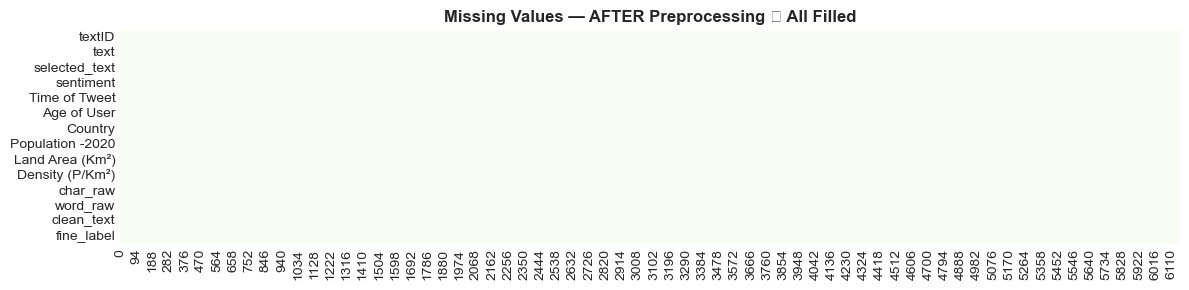

In [14]:
# 5.1 Null heatmap AFTER
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(train_df.isnull().T, cbar=False, cmap='Greens', ax=ax)
ax.set_title('Missing Values — AFTER Preprocessing ✅ All Filled', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_after_nulls.png', dpi=150, bbox_inches='tight')
plt.show()

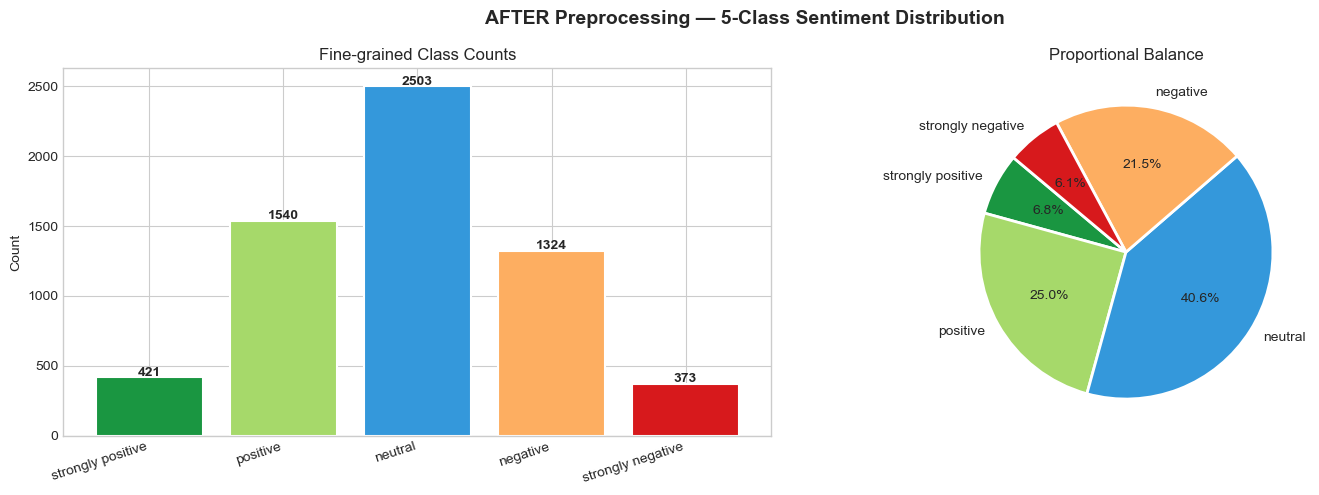

In [15]:
# 5.2 5-class distribution with reason colours
ordered5 = ['strongly positive','positive','neutral','negative','strongly negative']
fl = train_df['fine_label'].value_counts().reindex(ordered5)
bar5 = [COLORS5[l] for l in ordered5]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('AFTER Preprocessing — 5-Class Sentiment Distribution', fontsize=14, fontweight='bold')

bars = axes[0].bar(ordered5, fl.values, color=bar5, edgecolor='white', linewidth=1.5)
axes[0].set_title('Fine-grained Class Counts')
axes[0].set_xticklabels(ordered5, rotation=18, ha='right')
axes[0].set_ylabel('Count')
for bar, v in zip(bars, fl.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 str(int(v)), ha='center', fontweight='bold')

axes[1].pie(fl.values, labels=ordered5, autopct='%1.1f%%',
            colors=bar5, startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Proportional Balance')
plt.tight_layout()
plt.savefig('eda_after_5class.png', dpi=150, bbox_inches='tight')
plt.show()

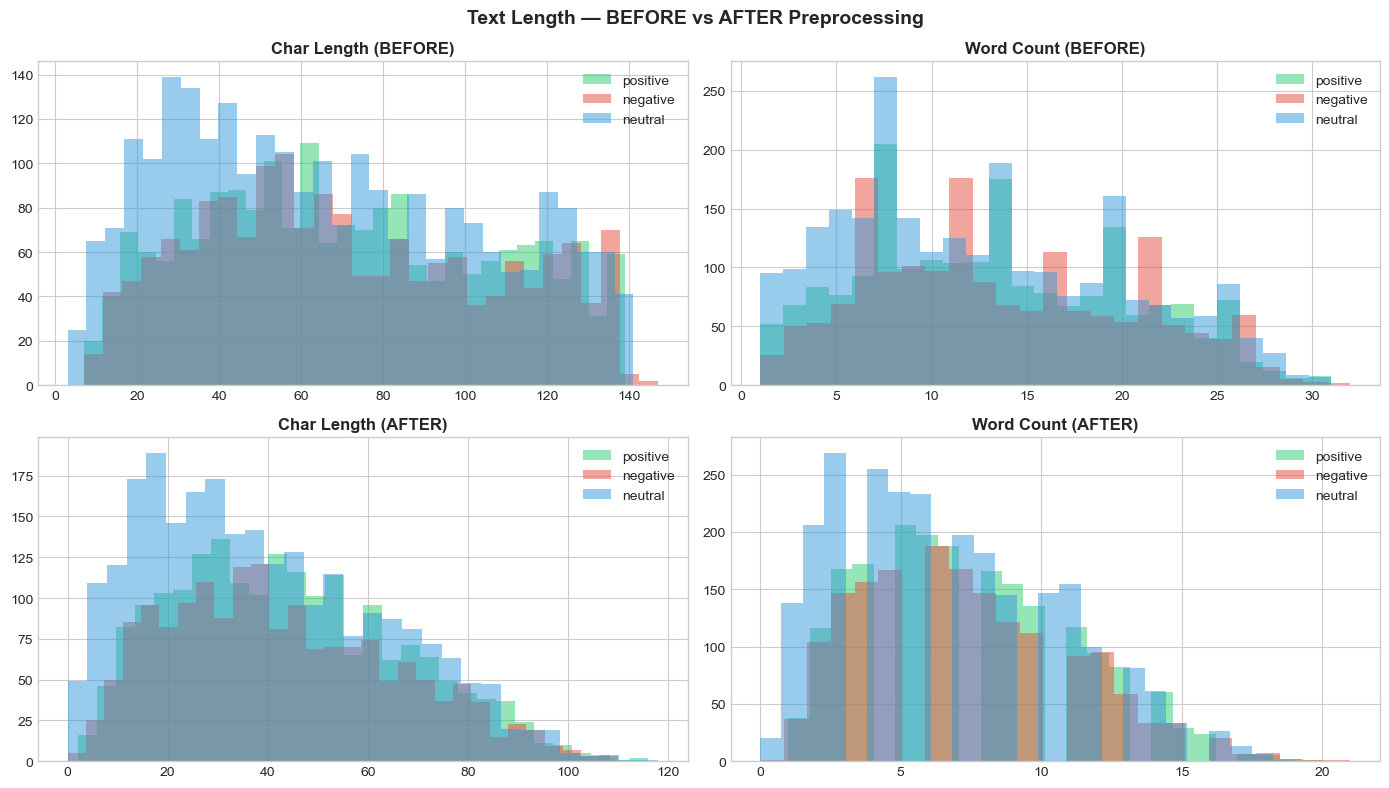

In [16]:
# 5.3 Before vs After text length side-by-side
train_df['char_clean'] = train_df['clean_text'].apply(len)
train_df['word_clean'] = train_df['clean_text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Text Length — BEFORE vs AFTER Preprocessing', fontsize=14, fontweight='bold')
for s, c in COLORS.items():
    sub = train_df[train_df['sentiment'] == s]
    axes[0,0].hist(sub['char_raw'],   alpha=0.5, label=s, color=c, bins=30)
    axes[0,1].hist(sub['word_raw'],   alpha=0.5, label=s, color=c, bins=25)
    axes[1,0].hist(sub['char_clean'], alpha=0.5, label=s, color=c, bins=30)
    axes[1,1].hist(sub['word_clean'], alpha=0.5, label=s, color=c, bins=25)

titles = ['Char Length (BEFORE)','Word Count (BEFORE)','Char Length (AFTER)','Word Count (AFTER)']
for ax, t in zip(axes.flat, titles):
    ax.set_title(t, fontweight='bold'); ax.legend()
plt.tight_layout()
plt.savefig('eda_length_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

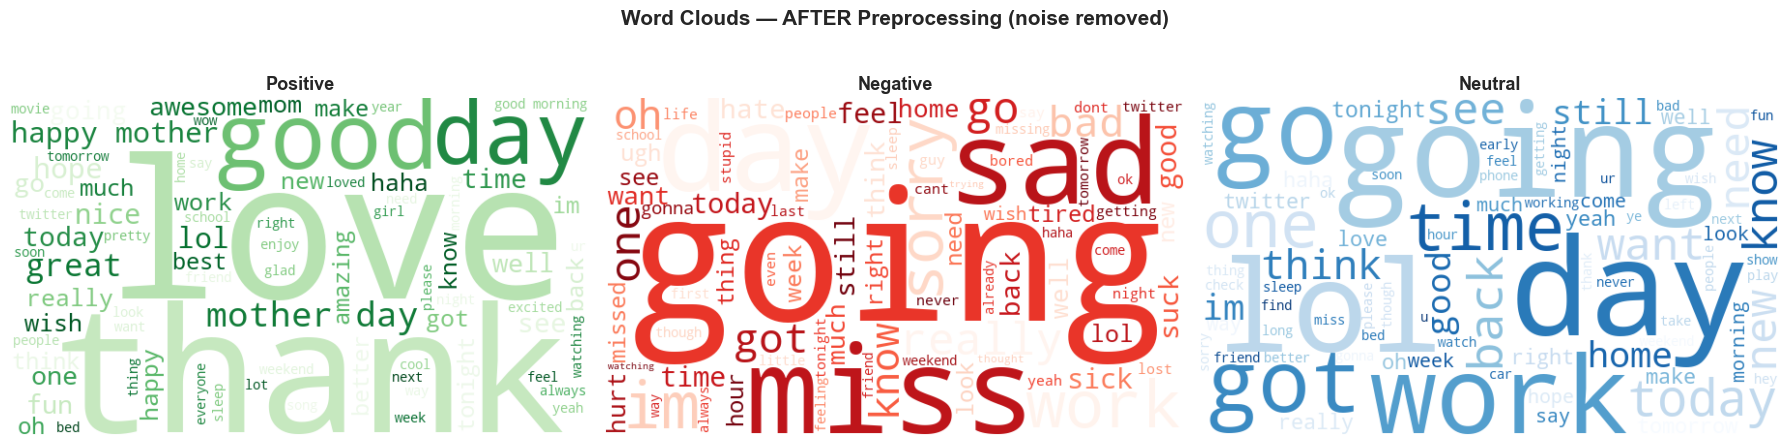

In [17]:
# 5.4 Word Clouds AFTER cleaning
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Word Clouds — AFTER Preprocessing (noise removed)', fontsize=15, fontweight='bold')
for ax, s, cm in zip(axes, ['positive','negative','neutral'], cmaps):
    txt = ' '.join(train_df[train_df['sentiment']==s]['clean_text'].astype(str))
    wc = WordCloud(width=600, height=350, background_color='white',
                   colormap=cm, max_words=80).generate(txt or 'empty')
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(s.capitalize(), fontsize=13, fontweight='bold'); ax.axis('off')
plt.tight_layout()
plt.savefig('eda_after_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

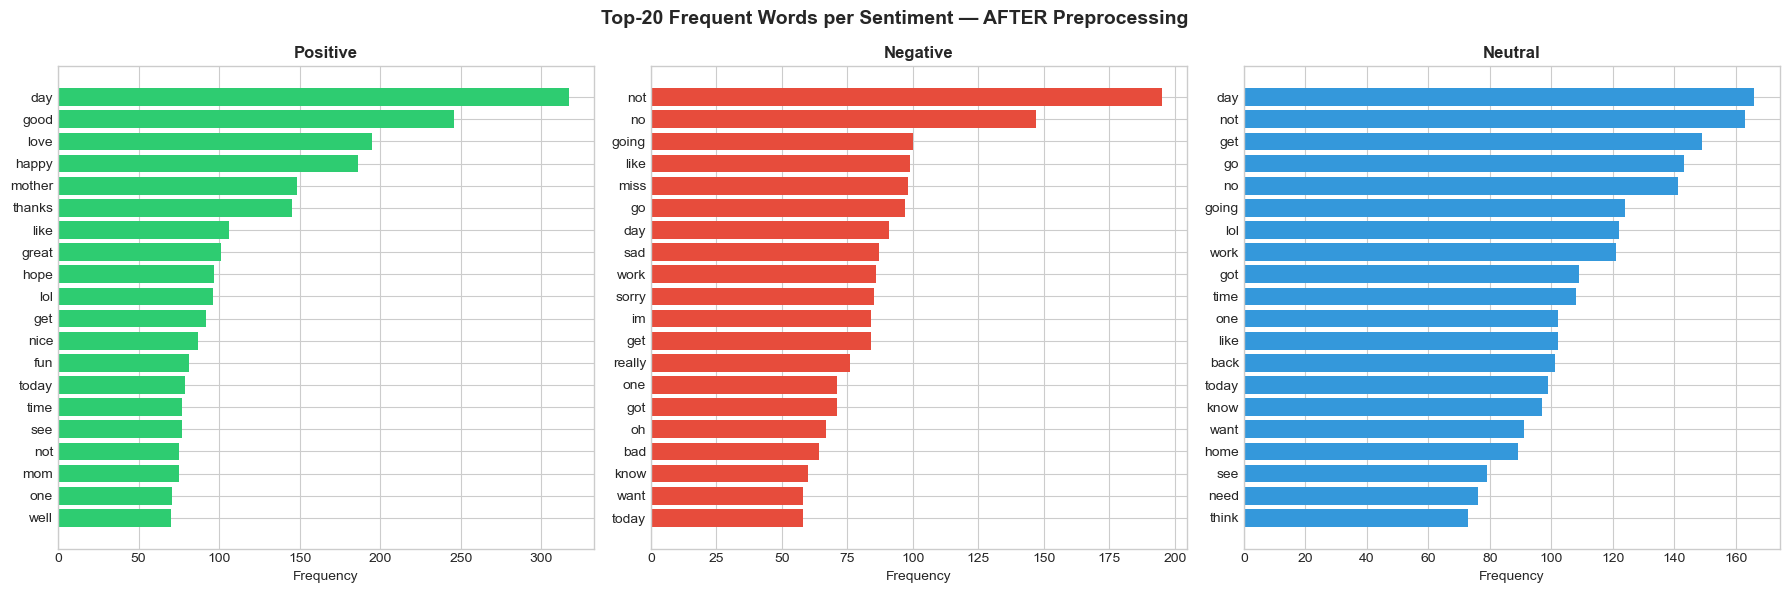

In [18]:
# 5.5 Top-20 words per class AFTER
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Top-20 Frequent Words per Sentiment — AFTER Preprocessing', fontsize=14, fontweight='bold')
for ax, s, c in zip(axes, ['positive','negative','neutral'], [COLORS[k] for k in COLORS]):
    words = ' '.join(train_df[train_df['sentiment']==s]['clean_text']).split()
    freq  = Counter(words).most_common(20)
    if freq:
        w, cnt = zip(*freq)
        ax.barh(list(w)[::-1], list(cnt)[::-1], color=c)
    ax.set_title(f'{s.capitalize()}', fontweight='bold'); ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig('eda_after_topwords.png', dpi=150, bbox_inches='tight')
plt.show()

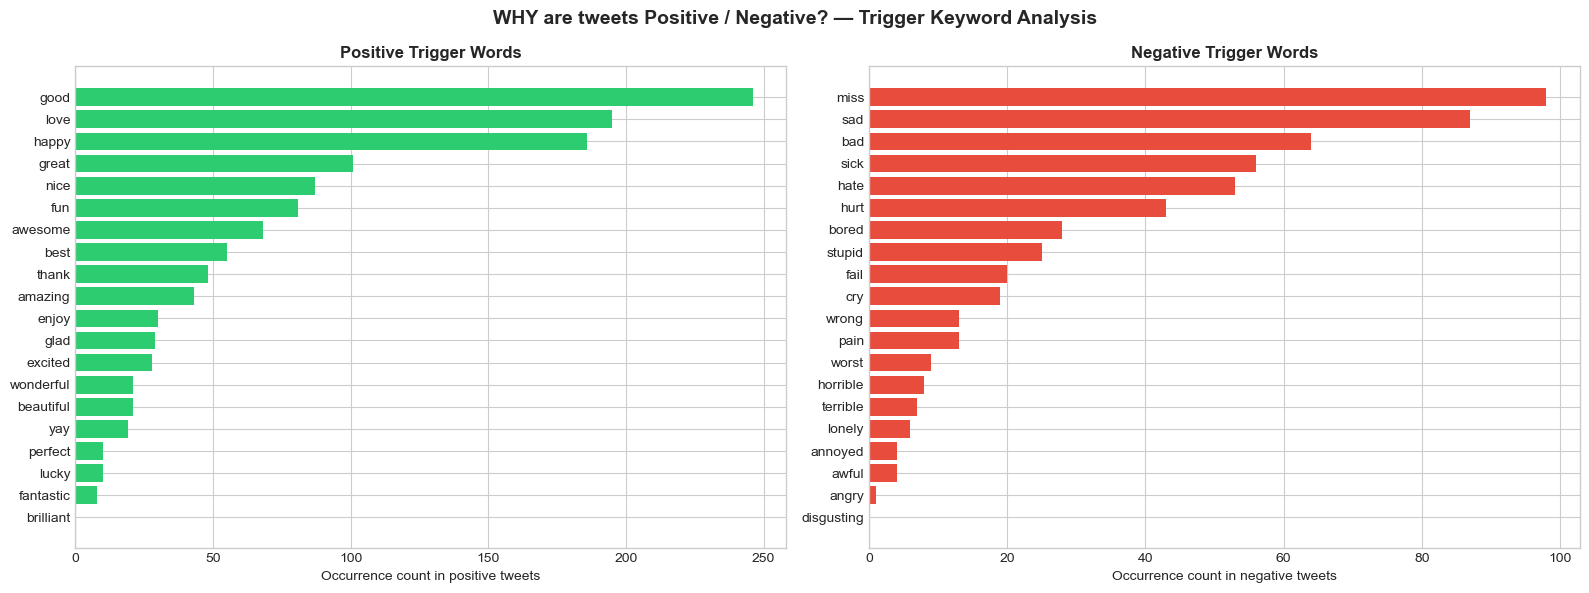

In [19]:
# 5.6 WHY positive/negative — keyword trigger chart
POS_KEYS = ['love','great','good','happy','thank','awesome','nice','best',
            'wonderful','excited','amazing','glad','fun','enjoy','yay',
            'beautiful','fantastic','perfect','brilliant','lucky']
NEG_KEYS = ['hate','sad','bad','terrible','worst','awful','miss','cry',
            'annoyed','angry','fail','sick','wrong','hurt','pain',
            'bored','stupid','disgusting','horrible','lonely']

pos_txt = ' '.join(train_df[train_df['sentiment']=='positive']['clean_text'])
neg_txt = ' '.join(train_df[train_df['sentiment']=='negative']['clean_text'])

pos_freq = {k: pos_txt.split().count(k) for k in POS_KEYS}
neg_freq = {k: neg_txt.split().count(k) for k in NEG_KEYS}

pos_s = pd.Series(pos_freq).sort_values(ascending=False)
neg_s = pd.Series(neg_freq).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('WHY are tweets Positive / Negative? — Trigger Keyword Analysis', fontsize=14, fontweight='bold')

axes[0].barh(pos_s.index[::-1], pos_s.values[::-1], color='#2ecc71')
axes[0].set_title('Positive Trigger Words', fontweight='bold')
axes[0].set_xlabel('Occurrence count in positive tweets')

axes[1].barh(neg_s.index[::-1], neg_s.values[::-1], color='#e74c3c')
axes[1].set_title('Negative Trigger Words', fontweight='bold')
axes[1].set_xlabel('Occurrence count in negative tweets')

plt.tight_layout()
plt.savefig('eda_why_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

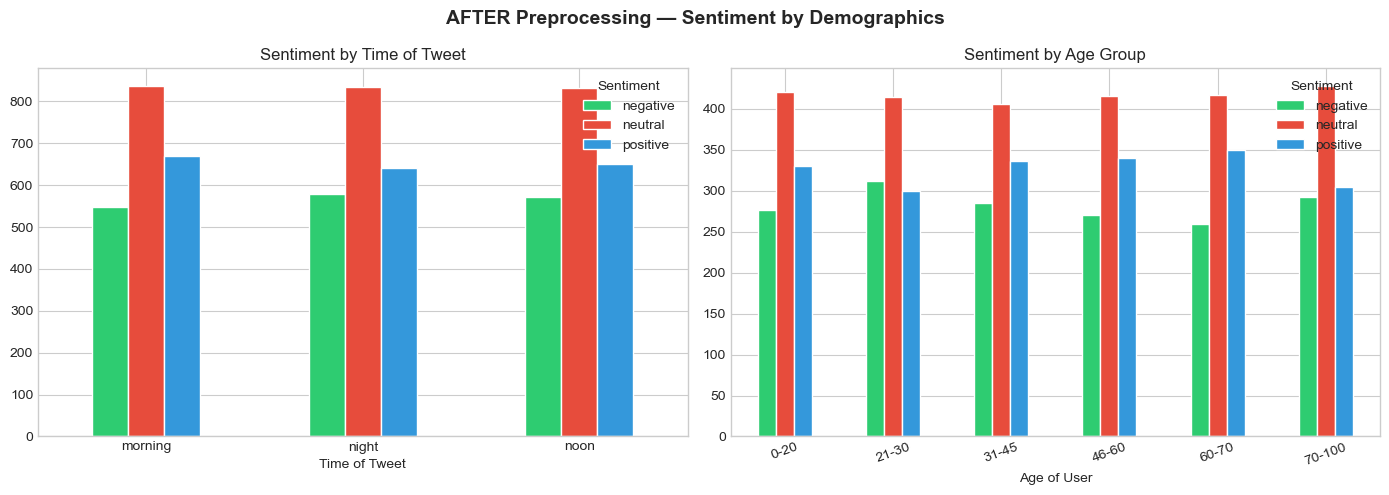

In [20]:
# 5.7 Sentiment breakdown by Time of Day and Age of User
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('AFTER Preprocessing — Sentiment by Demographics', fontsize=14, fontweight='bold')

time_sent = train_df.groupby(['Time of Tweet','sentiment']).size().unstack(fill_value=0)
time_sent.plot(kind='bar', ax=axes[0], color=list(COLORS.values()), edgecolor='white')
axes[0].set_title('Sentiment by Time of Tweet'); axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Sentiment')

age_sent = train_df.groupby(['Age of User','sentiment']).size().unstack(fill_value=0)
age_sent.plot(kind='bar', ax=axes[1], color=list(COLORS.values()), edgecolor='white')
axes[1].set_title('Sentiment by Age Group'); axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20)
axes[1].legend(title='Sentiment')

plt.tight_layout()
plt.savefig('eda_after_demographics_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

## 🤖 6. BERT Embeddings (DistilBERT)

In [21]:
MODEL_NAME = 'distilbert-base-uncased'
print(f'Loading {MODEL_NAME}...')
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME)
bert_model.eval()
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
bert_model = bert_model.to(DEVICE)
print(f'Model on {DEVICE}')

Loading distilbert-base-uncased...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model on cpu


In [ ]:
def get_bert_embeddings(texts, batch_size=64, max_len=128):
    all_embs = []
    for i in tqdm(range(0, len(texts), batch_size), desc='BERT'):
        batch = list(texts[i:i+batch_size])
        enc   = tokenizer(batch, padding=True, truncation=True,
                          max_length=max_len, return_tensors='pt')
        enc   = {k: v.to(DEVICE) for k, v in enc.items()}
        with torch.no_grad():
            out = bert_model(**enc)
        cls = out.last_hidden_state[:, 0, :].cpu().numpy()
        all_embs.append(cls)
    return np.vstack(all_embs)

print('Generating BERT embeddings for training set...')
X_bert = get_bert_embeddings(train_df['clean_text'].tolist())
print(f'✅ Embeddings shape: {X_bert.shape}')

Generating BERT embeddings for training set...


BERT:   0%|          | 0/97 [00:00<?, ?it/s]

In [ ]:
le = LabelEncoder()
y  = le.fit_transform(train_df['sentiment'])
joblib.dump(le, 'label_encoder.pkl')
print('Label map:', dict(zip(le.classes_, le.transform(le.classes_))))

X_train, X_val, y_train, y_val = train_test_split(
    X_bert, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f'Train {X_train.shape} | Val {X_val.shape}')

## 🏋️ 7. Train Three Models

In [ ]:
# ── Logistic Regression ──────────────────────────────────────────────────────
print('Training Logistic Regression...')
lr = LogisticRegression(C=5.0, max_iter=1000, solver='lbfgs',
                         multi_class='multinomial', random_state=SEED)
lr.fit(X_train, y_train)
lr_pred  = lr.predict(X_val)
lr_acc   = accuracy_score(y_val, lr_pred)
lr_f1    = f1_score(y_val, lr_pred, average='weighted')
print(f'  Accuracy: {lr_acc:.4f}  |  Weighted F1: {lr_f1:.4f}')

In [ ]:
# ── Naive Bayes (Gaussian — handles dense BERT embeddings) ───────────────────
print('Training Naive Bayes...')
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred  = nb.predict(X_val)
nb_acc   = accuracy_score(y_val, nb_pred)
nb_f1    = f1_score(y_val, nb_pred, average='weighted')
print(f'  Accuracy: {nb_acc:.4f}  |  Weighted F1: {nb_f1:.4f}')

In [ ]:
# ── SVM ───────────────────────────────────────────────────────────────────────
print('Training SVM (this takes a few minutes)...')
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=SEED)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_val)
svm_acc  = accuracy_score(y_val, svm_pred)
svm_f1   = f1_score(y_val, svm_pred, average='weighted')
print(f'  Accuracy: {svm_acc:.4f}  |  Weighted F1: {svm_f1:.4f}')

## 📈 8. Evaluation Visualisations

In [ ]:
# 8.1 Accuracy & F1 bar comparison
model_names = ['Logistic Regression', 'Naive Bayes', 'SVM']
accs = [lr_acc, nb_acc, svm_acc]
f1s  = [lr_f1,  nb_f1,  svm_f1]
mcols = ['#3498db', '#e67e22', '#9b59b6']

x = np.arange(len(model_names))
w = 0.35
fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x-w/2, [a*100 for a in accs], w, label='Accuracy (%)',    color=mcols, alpha=0.88)
b2 = ax.bar(x+w/2, [f*100 for f in f1s],  w, label='Weighted F1 (%)', color=mcols, alpha=0.45, hatch='///')
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Comparison — Accuracy & Weighted F1 on Validation Set',
             fontsize=14, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylim(0, 105); ax.legend(fontsize=11)
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.6,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 8.2 Confusion matrices (3 side by side)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — Validation Set', fontsize=14, fontweight='bold')
for ax, preds, name in zip(axes, [lr_pred, nb_pred, svm_pred], model_names):
    cm = confusion_matrix(y_val, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 8.3 Per-class F1 heatmap
reports = {}
for name, preds in [('LR', lr_pred), ('NB', nb_pred), ('SVM', svm_pred)]:
    r = classification_report(y_val, preds, target_names=le.classes_, output_dict=True)
    reports[name] = {cls: r[cls]['f1-score'] for cls in le.classes_}
rep_df = pd.DataFrame(reports).T

plt.figure(figsize=(8, 3))
sns.heatmap(rep_df, annot=True, fmt='.3f', cmap='YlGn', vmin=0, vmax=1)
plt.title('Per-Class F1 Score by Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n===== Full Classification Reports =====')
for name, preds in [('Logistic Regression', lr_pred), ('Naive Bayes', nb_pred), ('SVM', svm_pred)]:
    print(f'\n--- {name} ---')
    print(classification_report(y_val, preds, target_names=le.classes_))

In [ ]:
# 8.4 5-fold Cross-Validation
print('Running 5-fold CV on full dataset...')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}
for name, model in [('LR', lr), ('NB', nb), ('SVM', svm)]:
    scores = cross_val_score(model, X_bert, y, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f'  {name}: {scores.mean():.4f} ± {scores.std():.4f}')

# Box plot of CV scores
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
ax.set_title('5-Fold CV Accuracy Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy')
plt.tight_layout()
plt.savefig('cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 💾 9. Export Everything for Streamlit

In [ ]:
joblib.dump(lr,  'lr_model.pkl')
joblib.dump(nb,  'nb_model.pkl')
joblib.dump(svm, 'svm_model.pkl')
joblib.dump(le,  'label_encoder.pkl')

meta = {
    'Logistic Regression': {'accuracy': round(lr_acc,4),  'f1': round(lr_f1,4)},
    'Naive Bayes':         {'accuracy': round(nb_acc,4),  'f1': round(nb_f1,4)},
    'SVM':                 {'accuracy': round(svm_acc,4), 'f1': round(svm_f1,4)},
}
with open('model_meta.json','w') as f:
    json.dump(meta, f, indent=2)

train_df[['clean_text','sentiment','fine_label']].to_csv('train_for_frontend.csv', index=False)

print('✅ Saved:')
for fn in ['lr_model.pkl','nb_model.pkl','svm_model.pkl','label_encoder.pkl',
           'model_meta.json','train_for_frontend.csv']:
    print('  ', fn)

## 🧪 10. Sanity Test — Fine-grained Predictions

In [ ]:
def predict_all_models(text):
    cleaned = clean_text(text)
    enc = tokenizer([cleaned], padding=True, truncation=True,
                    max_length=128, return_tensors='pt')
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    with torch.no_grad():
        out = bert_model(**enc)
    emb = out.last_hidden_state[:, 0, :].cpu().numpy()

    results = {}
    for name, model in [('Logistic Regression', lr), ('Naive Bayes', nb), ('SVM', svm)]:
        base  = le.inverse_transform(model.predict(emb))[0]
        proba = model.predict_proba(emb)[0]
        conf  = float(max(proba))
        # 3-class → 5-class
        if base == 'positive':
            fine = 'strongly positive' if conf >= 0.70 else 'positive'
        elif base == 'negative':
            fine = 'strongly negative' if conf >= 0.70 else 'negative'
        else:
            fine = 'neutral'
        results[name] = {'fine': fine, 'base': base, 'confidence': conf,
                         'proba': dict(zip(le.classes_, proba.round(4)))}
    return results

tests = [
    "I absolutely LOVE this! Best day ever!!!",
    "This is okay I suppose.",
    "I hate everything about this. Absolutely terrible.",
    "Just heading home.",
    "Sooo SAD I will miss you here in San Diego!!!",
    "Not happy at all, this is wrong."
]

print(f'{"Tweet":<50} {"LR":<22} {"NB":<22} {"SVM":<22}')
print('-' * 120)
for t in tests:
    res = predict_all_models(t)
    row = f'{t[:48]:<50}'
    for m in ['Logistic Regression','Naive Bayes','SVM']:
        row += f' {res[m]["fine"]:<22}'
    print(row)

---
## ✅ Notebook Complete!

Copy these files into your Streamlit folder:
```
lr_model.pkl  |  nb_model.pkl  |  svm_model.pkl
label_encoder.pkl  |  model_meta.json  |  train_for_frontend.csv
```
Then run: `streamlit run app.py`